# Exploratory Data Analysis (EDA)

**Dataset:** Heart Failure Clinical Records Dataset

This notebook performs a complete EDA workflow:
- Load and inspect the dataset
- Check data quality (types, missing values, duplicates)
- Summary statistics
- Univariate analysis (distributions)
- Bivariate analysis vs. the target (`DEATH_EVENT`)
- Correlation analysis
- Key insights & conclusions

> **Target column:** `DEATH_EVENT` (1 = death, 0 = survived during follow-up)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 1. Dataset overview

In [3]:
df.shape

(299, 13)

In [4]:
df.columns.tolist()

['age',
 'anaemia',
 'creatinine_phosphokinase',
 'diabetes',
 'ejection_fraction',
 'high_blood_pressure',
 'platelets',
 'serum_creatinine',
 'serum_sodium',
 'sex',
 'smoking',
 'time',
 'DEATH_EVENT']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


### Column meaning (quick guide)

Typical meanings in this dataset:
- `age`: patient age (years)
- `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, `smoking`: binary indicators (0/1)
- `creatinine_phosphokinase`: enzyme level (mcg/L)
- `ejection_fraction`: % of blood leaving the heart at each contraction
- `platelets`: platelets in blood (kiloplatelets/mL)
- `serum_creatinine`: level of serum creatinine (mg/dL)
- `serum_sodium`: level of serum sodium (mEq/L)
- `time`: follow-up period (days)
- `DEATH_EVENT`: target label (1 = death, 0 = survived)

## 2. Data quality checks

- Missing values
- Duplicate rows
- Basic validity (binary columns are only 0/1)

In [6]:
df.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
binary_cols = ["anaemia","diabetes","high_blood_pressure","sex","smoking","DEATH_EVENT"]
{col: sorted(df[col].unique().tolist()) for col in binary_cols}

{'anaemia': [0, 1],
 'diabetes': [0, 1],
 'high_blood_pressure': [0, 1],
 'sex': [0, 1],
 'smoking': [0, 1],
 'DEATH_EVENT': [0, 1]}

**Observation:** This dataset has no missing values and no duplicates. Binary columns are clean (0/1).

## 3. Summary statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [10]:
for col in ["anaemia","diabetes","high_blood_pressure","sex","smoking","DEATH_EVENT"]:
    print(f"\n{col} value counts:")
    print(df[col].value_counts().sort_index())


anaemia value counts:
anaemia
0    170
1    129
Name: count, dtype: int64

diabetes value counts:
diabetes
0    174
1    125
Name: count, dtype: int64

high_blood_pressure value counts:
high_blood_pressure
0    194
1    105
Name: count, dtype: int64

sex value counts:
sex
0    105
1    194
Name: count, dtype: int64

smoking value counts:
smoking
0    203
1     96
Name: count, dtype: int64

DEATH_EVENT value counts:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


### Target balance

Understanding how balanced the target is helps interpret model performance later.

In [11]:
death_counts = df["DEATH_EVENT"].value_counts().sort_index()
death_counts, death_counts / len(df)

(DEATH_EVENT
 0    203
 1     96
 Name: count, dtype: int64,
 DEATH_EVENT
 0    0.67893
 1    0.32107
 Name: count, dtype: float64)

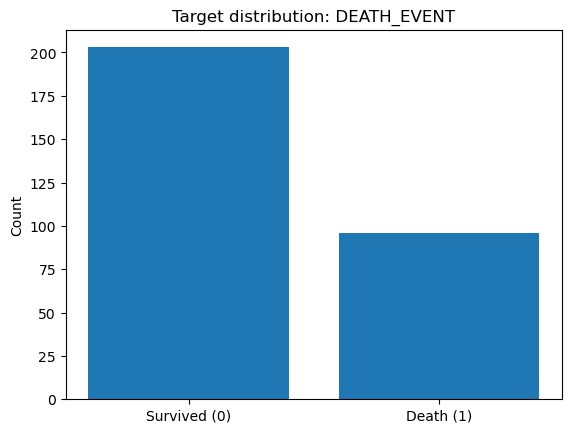

In [12]:
plt.figure()
plt.bar(["Survived (0)","Death (1)"], death_counts.values)
plt.title("Target distribution: DEATH_EVENT")
plt.ylabel("Count")
plt.show()

## 4. Univariate analysis (single-variable)

**Goal:** detect skewness, outliers, and typical ranges.

In [13]:
numeric_cols = ["age","creatinine_phosphokinase","ejection_fraction","platelets",
                "serum_creatinine","serum_sodium","time"]
binary_cols = ["anaemia","diabetes","high_blood_pressure","sex","smoking"]

numeric_cols, binary_cols

(['age',
  'creatinine_phosphokinase',
  'ejection_fraction',
  'platelets',
  'serum_creatinine',
  'serum_sodium',
  'time'],
 ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking'])

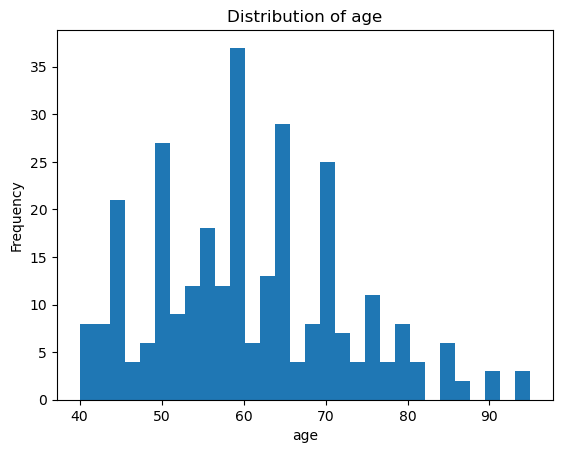

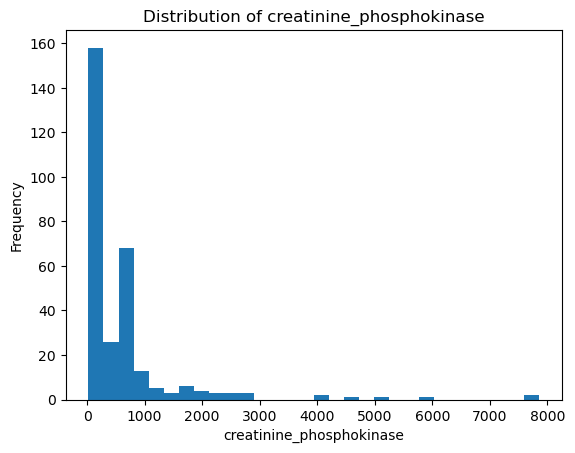

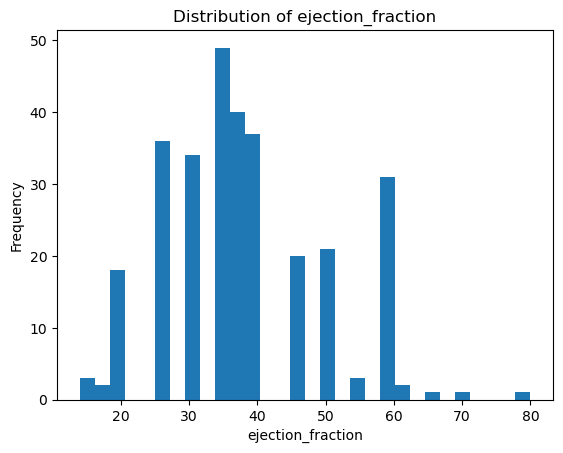

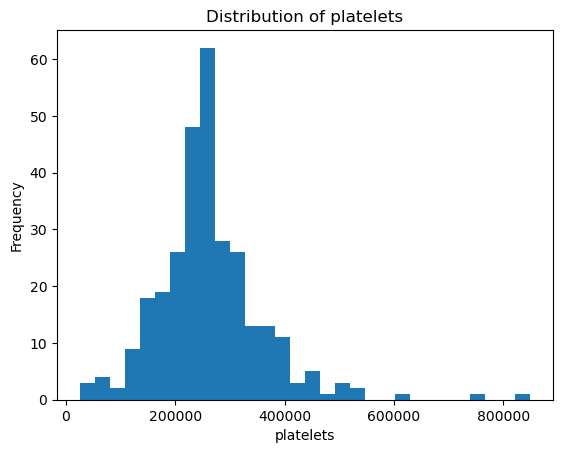

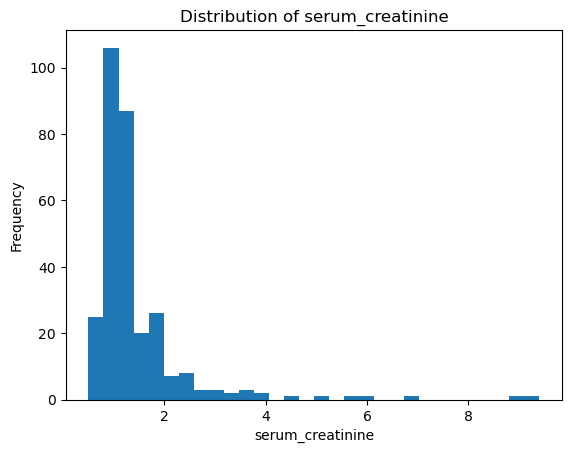

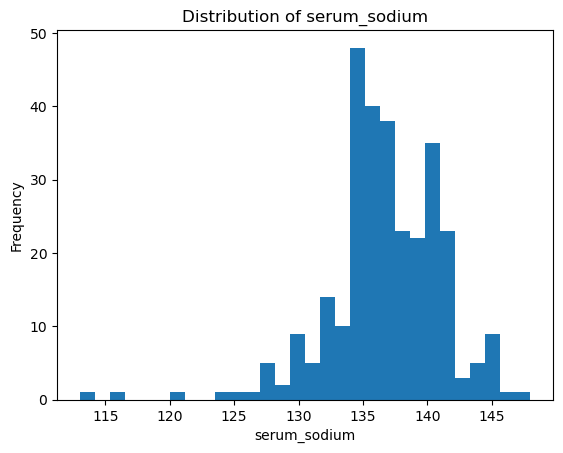

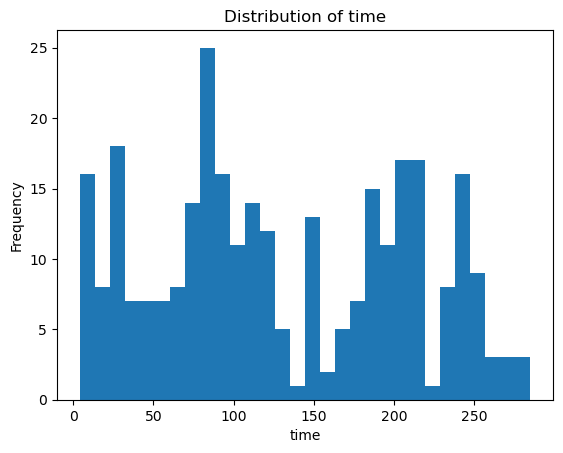

In [14]:
for col in numeric_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

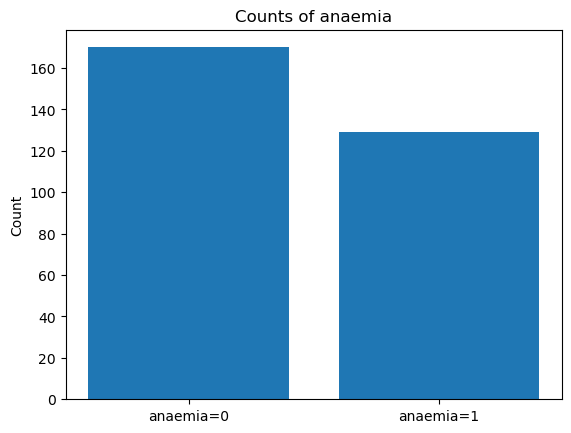

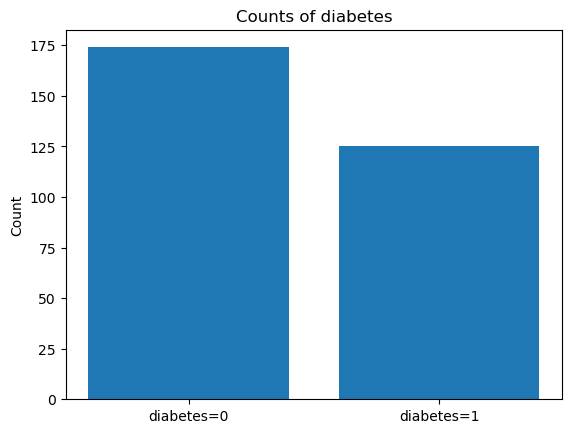

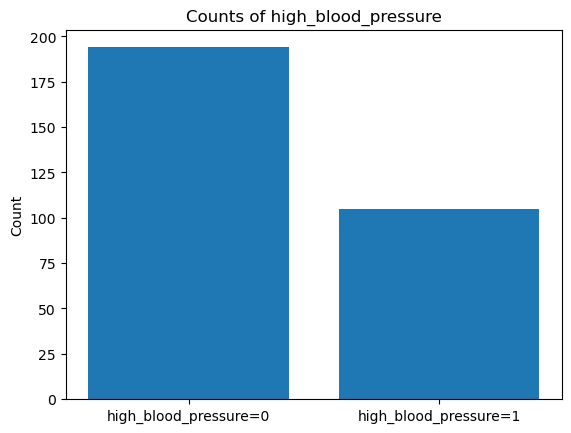

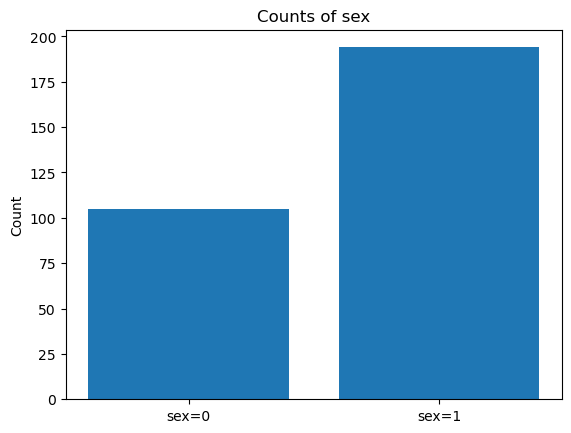

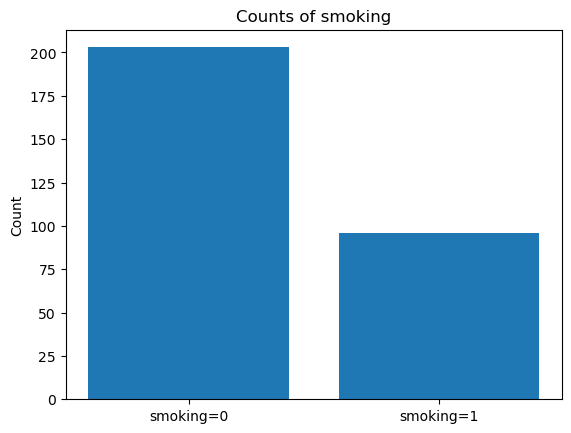

In [15]:
for col in binary_cols:
    vc = df[col].value_counts().sort_index()
    plt.figure()
    plt.bar([f"{col}=0", f"{col}=1"], vc.values)
    plt.title(f"Counts of {col}")
    plt.ylabel("Count")
    plt.show()

## 5. Bivariate analysis vs. outcome (`DEATH_EVENT`)

**Goal:** identify features that differ noticeably by outcome.

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


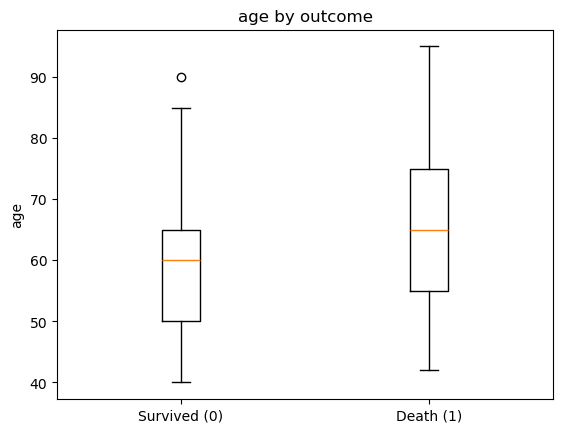

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


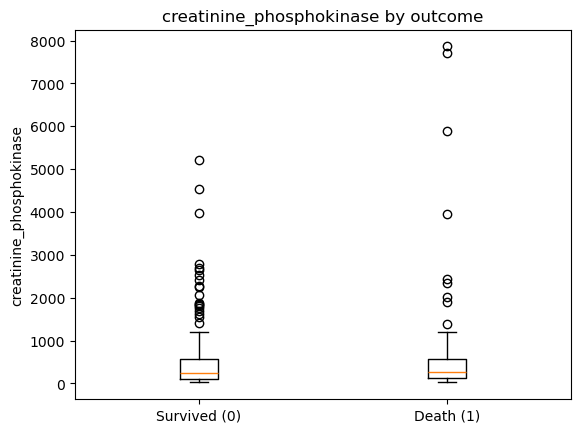

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


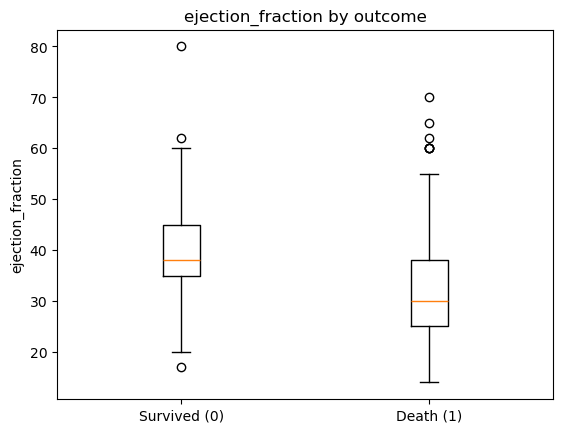

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


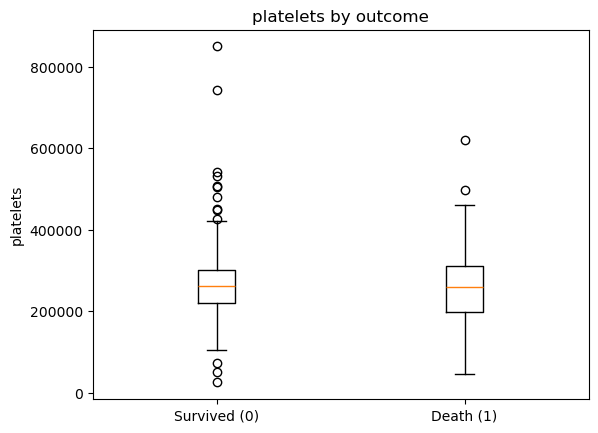

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


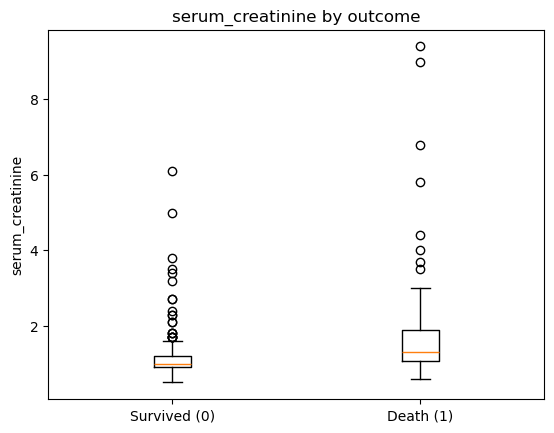

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


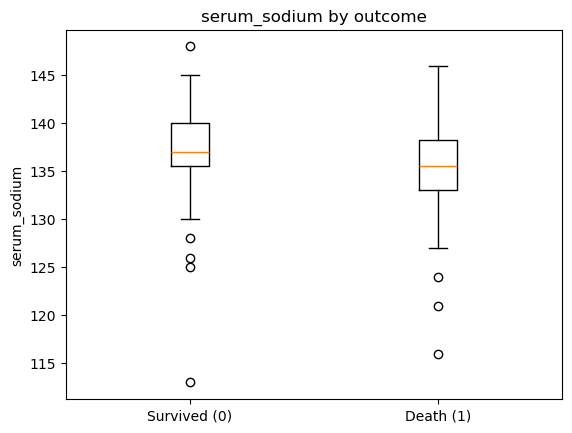

C:\Users\stdre\AppData\Local\Temp\ipykernel_36932\3086782928.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])


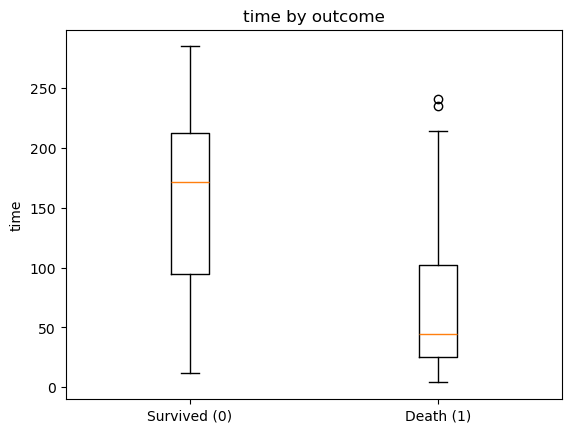

In [16]:
for col in numeric_cols:
    plt.figure()
    data0 = df[df["DEATH_EVENT"]==0][col]
    data1 = df[df["DEATH_EVENT"]==1][col]
    plt.boxplot([data0, data1], labels=["Survived (0)", "Death (1)"])
    plt.title(f"{col} by outcome")
    plt.ylabel(col)
    plt.show()

In [17]:
for col in binary_cols:
    rate = df.groupby(col)["DEATH_EVENT"].mean()
    count = df[col].value_counts().sort_index()
    print(f"\n{col}:")
    print("Counts:", count.to_dict())
    print("Death rate (mean DEATH_EVENT):", rate.to_dict())


anaemia:
Counts: {0: 170, 1: 129}
Death rate (mean DEATH_EVENT): {0: 0.29411764705882354, 1: 0.35658914728682173}

diabetes:
Counts: {0: 174, 1: 125}
Death rate (mean DEATH_EVENT): {0: 0.3218390804597701, 1: 0.32}

high_blood_pressure:
Counts: {0: 194, 1: 105}
Death rate (mean DEATH_EVENT): {0: 0.29381443298969073, 1: 0.37142857142857144}

sex:
Counts: {0: 105, 1: 194}
Death rate (mean DEATH_EVENT): {0: 0.3238095238095238, 1: 0.31958762886597936}

smoking:
Counts: {0: 203, 1: 96}
Death rate (mean DEATH_EVENT): {0: 0.3251231527093596, 1: 0.3125}


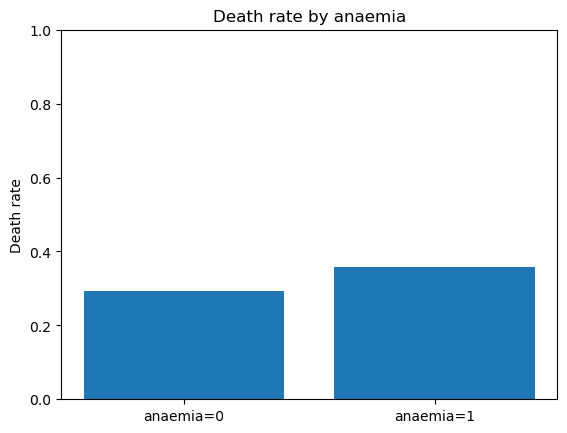

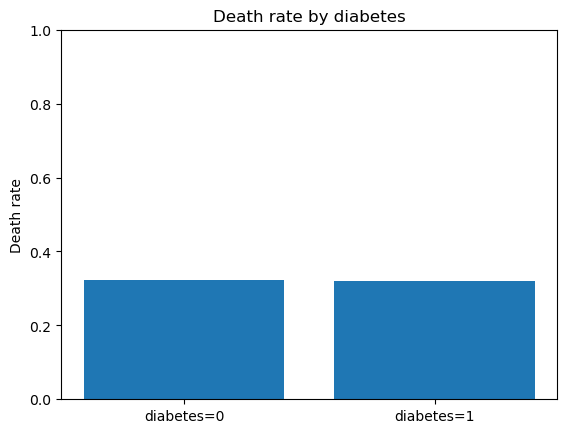

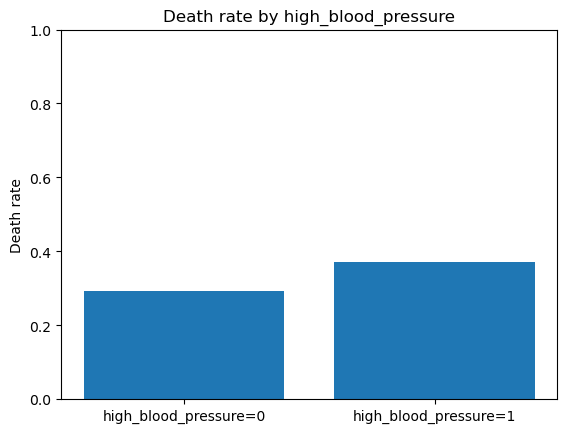

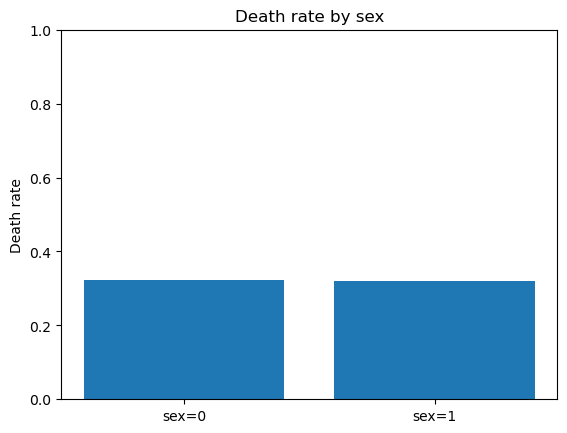

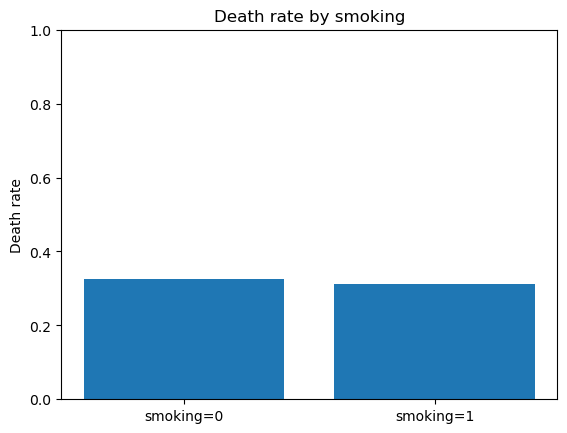

In [18]:
for col in binary_cols:
    rate = df.groupby(col)["DEATH_EVENT"].mean().sort_index()
    plt.figure()
    plt.bar([f"{col}=0", f"{col}=1"], rate.values)
    plt.title(f"Death rate by {col}")
    plt.ylabel("Death rate")
    plt.ylim(0, 1)
    plt.show()

## 6. Correlation analysis

In [19]:
corr = df.corr(numeric_only=True)
corr

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
age,1.000000,0.088006,-0.081584,-0.101012,0.060098,0.093289,-0.052354,0.159187,-0.045966,0.065430,0.018668,-0.224068,0.253729
anaemia,0.088006,1.000000,-0.190741,-0.012729,0.031557,0.038182,-0.043786,0.052174,0.041882,-0.094769,-0.107290,-0.141414,0.066270
creatinine_phosphokinase,-0.081584,-0.190741,1.000000,-0.009639,-0.044080,-0.070590,0.024463,-0.016408,0.059550,0.079791,0.002421,-0.009346,0.062728
diabetes,-0.101012,-0.012729,-0.009639,1.000000,-0.004850,-0.012732,0.092193,-0.046975,-0.089551,-0.157730,-0.147173,0.033726,-0.001943
ejection_fraction,0.060098,0.031557,-0.044080,-0.004850,1.000000,0.024445,0.072177,-0.011302,0.175902,-0.148386,-0.067315,0.041729,-0.268603
high_blood_pressure,0.093289,0.038182,-0.070590,-0.012732,0.024445,1.000000,0.049963,-0.004935,0.037109,-0.104615,-0.055711,-0.196439,0.079351
platelets,-0.052354,-0.043786,0.024463,0.092193,0.072177,0.049963,1.000000,-0.041198,0.062125,-0.125120,0.028234,0.010514,-0.049139
serum_creatinine,0.159187,0.052174,-0.016408,-0.046975,-0.011302,-0.004935,-0.041198,1.000000,-0.189095,0.006970,-0.027414,-0.149315,0.294278
serum_sodium,-0.045966,0.041882,0.059550,-0.089551,0.175902,0.037109,0.062125,-0.189095,1.000000,-0.027566,0.004813,0.087640,-0.195204
sex,0.065430,-0.094769,0.079791,-0.157730,-0.148386,-0.104615,-0.125120,0.006970,-0.027566,1.000000,0.445892,-0.015608,-0.004316


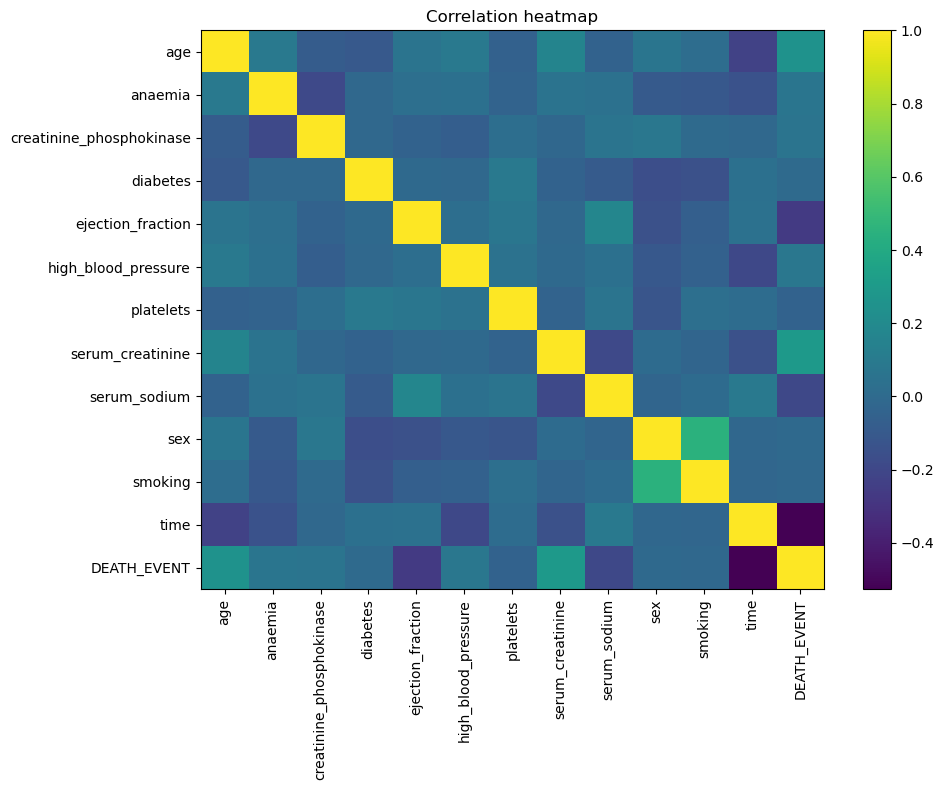

In [20]:
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

### Top correlations with the target

In [21]:
target_corr = corr["DEATH_EVENT"].sort_values()
target_corr

time                       -0.526964
ejection_fraction          -0.268603
serum_sodium               -0.195204
platelets                  -0.049139
smoking                    -0.012623
sex                        -0.004316
diabetes                   -0.001943
creatinine_phosphokinase    0.062728
anaemia                     0.066270
high_blood_pressure         0.079351
age                         0.253729
serum_creatinine            0.294278
DEATH_EVENT                 1.000000
Name: DEATH_EVENT, dtype: float64

In [22]:
top_abs = target_corr.drop("DEATH_EVENT").abs().sort_values(ascending=False).head(8)
top_abs

time                        0.526964
serum_creatinine            0.294278
ejection_fraction           0.268603
age                         0.253729
serum_sodium                0.195204
high_blood_pressure         0.079351
anaemia                     0.066270
creatinine_phosphokinase    0.062728
Name: DEATH_EVENT, dtype: float64

## 7. Key insights

**Data quality**
- No missing values and no duplicate rows.
- Binary features are correctly encoded as 0/1.

**Target balance**
- `DEATH_EVENT` shows the proportion of death events vs. survivors; this affects evaluation metrics.

**Univariate observations**
- Some clinical measures can be skewed and may include outliers.
- Follow-up time (`time`) varies between patients.

**Bivariate observations (vs outcome)**
- Features that show visibly different distributions between outcome classes are candidates for strong predictors.
- Binary features can be compared via death-rate plots.

**Correlation**
- The correlation table provides a quick signal of which variables move with the outcome, but it should be supported by the bivariate plots above.

## 8. Conclusion

This EDA explored the heart failure clinical records dataset and examined distributions, group differences by outcome, and correlations.